# Exploratory Data Analysis

## Roles to Explore:

In [ ]:
# Run this cell to install required packages.
%pip install pandas datasets seaborn matplotlib

In [ ]:
%pip install ipywidgets



In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
#loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [3]:
# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], errors="coerce")
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter for Canada Data Analyst Roles

In [6]:
df_DA_CA = df[(df["job_country"] == "Canada") & (df["job_title"].str.contains("Data Analyst", case=False, na=False))]

In [18]:
df_DA_CA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
81,Data Analyst,Business Data Analyst,"Regina, SK, Canada",via ZipRecruiter,Full-time,False,Canada,2023-03-01 13:28:04,False,False,Canada,NaN,NaN,NaN,027 Parks Culture and Sport,NaN,NaN
225,Data Analyst,"Statistical Healthcare Data Analyst, Policy Re...",Anywhere,via LinkedIn,Full-time,True,Canada,2023-07-07 13:12:09,False,False,Canada,NaN,NaN,NaN,Policy Reporter,[r],{'programming': ['r']}
638,Data Analyst,Cognitive Data Analyst,Anywhere,via Indeed,Full-time,True,Canada,2023-05-10 13:19:23,False,False,Canada,NaN,NaN,NaN,Wysdom.AI,"[python, sql]","{'programming': ['python', 'sql']}"
779,Senior Data Analyst,Senior Healthcare Data Analyst,Canada,via BeBee Canada,Full-time,False,Canada,2023-06-27 13:32:20,False,False,Canada,NaN,NaN,NaN,Providence Health & Services,"[vba, sql, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr..."
867,Data Analyst,Lead Data Analyst [Remote],Anywhere,via LinkedIn,Full-time,True,Canada,2023-01-23 13:14:40,False,False,Canada,NaN,NaN,NaN,Talentify.io,"[sql, python, aws, redshift]","{'cloud': ['aws', 'redshift'], 'programming': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779685,Senior Data Analyst,Senior Data Analyst,Canada,via Trabajo.org,Full-time,False,Canada,2023-10-08 05:16:36,True,False,Canada,NaN,NaN,NaN,"Digital, Aristocrat","[sql, python, r, go, excel, slack, zoom]","{'analyst_tools': ['excel'], 'programming': ['..."
780676,Data Analyst,Junior Data Analyst,Canada,via BeBee Canada,Full-time,False,Canada,2023-09-27 05:20:32,False,False,Canada,NaN,NaN,NaN,RAP International,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
781319,Data Analyst,"Data Analyst, Product Development",Canada,via Trabajo.org,Full-time,False,Canada,2023-01-05 06:41:05,False,False,Canada,NaN,NaN,NaN,BRP,NaN,NaN
783652,Data Analyst,Industry Data Analyst Consultant,Canada,via BeBee Canada,Full-time,False,Canada,2023-07-03 06:31:19,False,False,Canada,NaN,NaN,NaN,IBM,[ibm cloud],{'cloud': ['ibm cloud']}


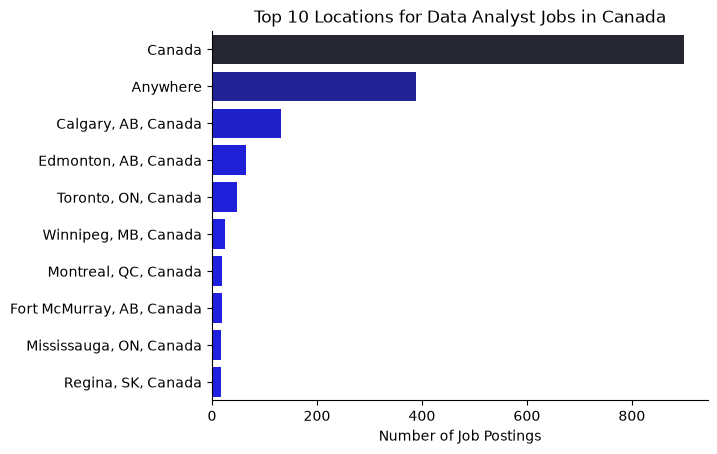

In [13]:
df_plot = df_DA_CA["job_location"].value_counts().head(10).to_frame()
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title("Top 10 Locations for Data Analyst Jobs in Canada")
plt.xlabel("Number of Job Postings")
plt.ylabel("")
plt.show()

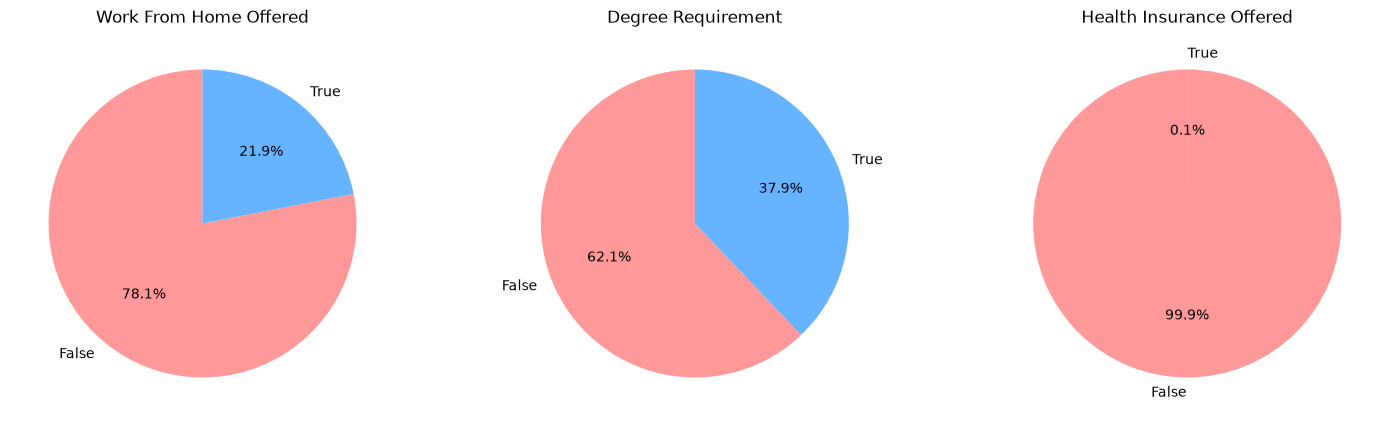

In [14]:
dict_columns = {
    "job_work_from_home": "Work From Home Offered",
    "job_no_degree_mention": "Degree Requirement",
    "job_health_insurance": "Health Insurance Offered"
}

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.set_size_inches(18, 5)

for i, (col, title) in enumerate(dict_columns.items()):
    ax[i].pie(df_DA_CA[col].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
    ax[i].set_title(title)
plt.show()